In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pymargins import Margins

rng = np.random.default_rng(42)
n = 2000
df = pd.DataFrame({
    "age": rng.integers(20, 75, n),
    "female": rng.binomial(1, 0.52, n),
    "treated": rng.binomial(1, 0.40, n),
    "firm": rng.integers(1, 50, n),
})
lp = -1.5 + 0.04 * df["age"] - 0.3 * df["female"] + 0.8 * df["treated"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm("y ~ age + female + treated", data=df,
              family=sm.families.Binomial()).fit()
m = Margins.log_scale(fit, at="overall")

In [2]:
from pymargins import Margins

# Heteroskedastic-robust HC3
m_hc3 = Margins.log_scale(fit, vcov="HC3")
print(m_hc3.dydx("age").summary())

# Cluster-robust
m_cl = Margins.log_scale(fit, vcov={"type": "cluster", "groups": df["firm"]})
print(m_cl.dydx("age").summary())

            Margins Result (delta, level=0.95)            
     estimate  std err          z  P>|z|  [95% Conf. Int.]
----------------------------------------------------------
age    0.0086   0.0397  -119.7598  0.000    0.0080, 0.0093

n = 2000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 0.208
Delta-vs-sim disagreement: 5.621%
            Margins Result (delta, level=0.95)            
     estimate  std err          z  P>|z|  [95% Conf. Int.]
----------------------------------------------------------
age    0.0086   0.0305  -155.7831  0.000    0.0081, 0.0092

n = 2000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 0.173
Delta-vs-sim disagreement: 4.608%


[Text(0, 0.5, 'SE of AME(age)')]

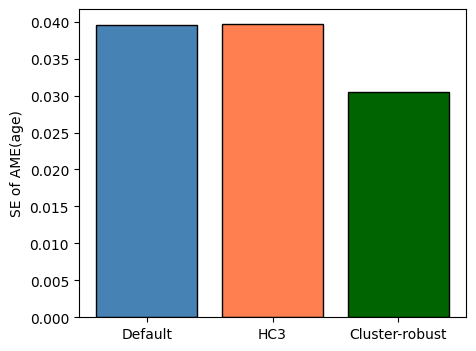

In [3]:
import matplotlib.pyplot as plt

res_ols = Margins.log_scale(fit, at="overall").dydx("age").to_frame()
res_hc3 = m_hc3.dydx("age").to_frame()
res_cl = m_cl.dydx("age").to_frame()

labels = ["Default", "HC3", "Cluster-robust"]
se_values = [res_ols["std_error"].iloc[0],
             res_hc3["std_error"].iloc[0],
             res_cl["std_error"].iloc[0]]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, se_values, color=["steelblue", "coral", "darkgreen"],
       edgecolor="black")
ax.set(ylabel="SE of AME(age)")